# Sentiment Analysis - CNN Model

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout, Input, BatchNormalization, Concatenate, Add, Activation, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from nltk.stem import WordNetLemmatizer

In [2]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils
from models import train_cnn

In [3]:
# due to error with allocating GPU memory, the CPU will be used
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [4]:
models_output_dir = '../outputs/models/cnn'

In [5]:
import fasttext
import fasttext.util

# define the model file path
model_path = "../data/embeddings/cc.en.300.bin"

# download the FastText model if it does not exist
if not os.path.exists(model_path):
    fasttext.util.download_model('en', if_exists='ignore')  # download English FastText model (300D)

# load the FastText model
fasttext_model = fasttext.load_model(model_path)

In [6]:
# preprocess and tokenize data
def preprocess_data(df, max_length=128, vocab_size=10000):
    # initialize tokenizer and lemmatizer
    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
    lemmatizer = WordNetLemmatizer()

    # remove missing or empty values
    df = df.dropna(subset=['Review']).copy()
    df = df[df['Review'].str.strip() != '']

    # extract texts and labels
    texts = df['Review'].astype(str).tolist()
    labels = df['Polarity'].values

    # apply lemmatization
    texts = [" ".join([lemmatizer.lemmatize(word) for word in text.split()]) for text in texts]

    # tokenize and pad sequences
    tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

    return padded_sequences, np.array(labels), tokenizer

In [7]:
# preprocess and tokenize data using existing tokenizer
def tokenize_with_existing_tokenizer(df, tokenizer, max_length):
    texts = df['Review'].astype(str).tolist()
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    labels = df['Polarity'].values
    return padded_sequences, labels

# 1. CNN Model - Amazon Books Reviews

## 1.1. Loading Data

In [8]:
# load the dataset
amazon_file = '../data/preprocessed/amazon.csv'
amazon_df = pd.read_csv(amazon_file, engine='python', encoding="ISO-8859-1")

In [9]:
# preview the data
amazon_df.head()

,Polarity,Review
0,0,As a Man Stinketh
1,1,MY FAVORITE!!
2,1,Epic novel
3,1,Very good source for Web Applications Development
4,1,Great fantasy


In [10]:
train_val_amazon_df, test_amazon_df = train_test_split(
    amazon_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=amazon_df['Polarity']
)

In [11]:
train_amazon_df, val_amazon_df = train_test_split(
    train_val_amazon_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_amazon_df['Polarity']
)

In [12]:
DataUtils.count_reviews_by_polarity(train_amazon_df)

Number of reviews with Polarity=1: 49382
Number of reviews with Polarity=0: 49382


In [13]:
DataUtils.count_reviews_by_polarity(val_amazon_df)

Number of reviews with Polarity=1: 10585
Number of reviews with Polarity=0: 10584


In [14]:
DataUtils.count_reviews_by_polarity(test_amazon_df)

Number of reviews with Polarity=1: 10582
Number of reviews with Polarity=0: 10583


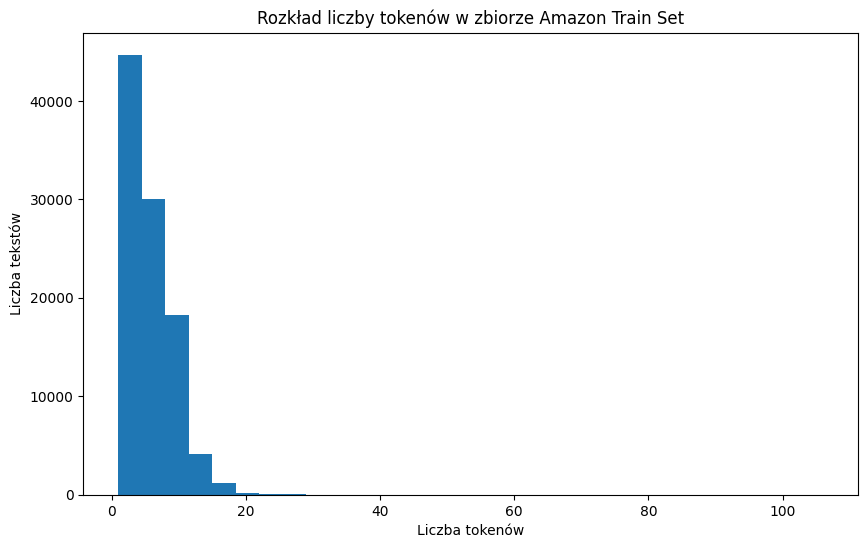

In [15]:
DataUtils.plot_token_distribution(train_amazon_df, "Amazon Train Set")

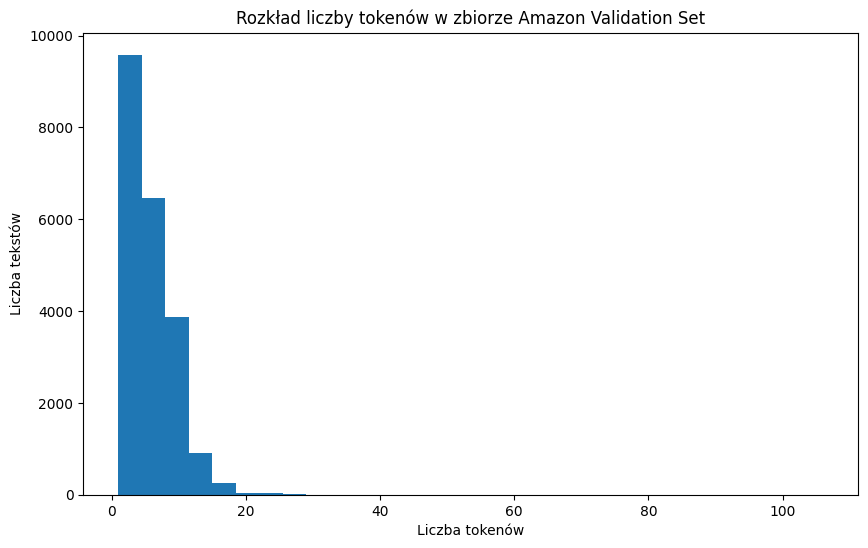

In [16]:
DataUtils.plot_token_distribution(val_amazon_df, "Amazon Validation Set")

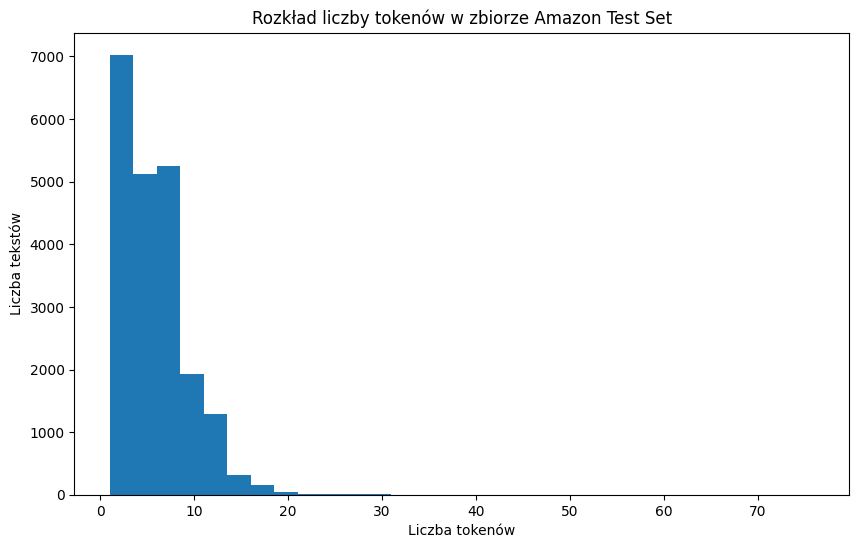

In [17]:
DataUtils.plot_token_distribution(test_amazon_df, "Amazon Test Set")

## 1.2. Data Preprocessing

In [18]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 32  # maximum length of input sequences

In [19]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_amazon_df, max_length=max_length, vocab_size=vocab_size)

In [20]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_amazon_df, tokenizer, max_length)

In [21]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_amazon_df, tokenizer, max_length)

## 1.3. Model Training

In [33]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [34]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [110]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Conv1D(filters=128, kernel_size=2, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [111]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [112]:
model_cnn.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_17 (Embedding)    (None, 32, 300)           3600000   
                                                                 
 conv1d_28 (Conv1D)          (None, 31, 128)           76928     
                                                                 
 batch_normalization_5 (Batc  (None, 31, 128)          512       
 hNormalization)                                                 
                                                                 
 global_max_pooling1d_15 (Gl  (None, 128)              0         
 obalMaxPooling1D)                                               
                                                                 
 dropout_25 (Dropout)        (None, 128)               0         
                                                                 
 dense_22 (Dense)            (None, 32)               

In [113]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [114]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 21s 7ms/step - loss: 0.4741 - accuracy: 0.7692 - val_loss: 0.3963 - val_accuracy: 0.8137
Epoch 2/10
3087/3087 [==============================] - 20s 6ms/step - loss: 0.4015 - accuracy: 0.8116 - val_loss: 0.3842 - val_accuracy: 0.8182
Epoch 3/10
3087/3087 [==============================] - 19s 6ms/step - loss: 0.3835 - accuracy: 0.8220 - val_loss: 0.3735 - val_accuracy: 0.8257
Epoch 4/10
3087/3087 [==============================] - 19s 6ms/step - loss: 0.3706 - accuracy: 0.8275 - val_loss: 0.3831 - val_accuracy: 0.8221
Epoch 5/10
3087/3087 [==============================] - 19s 6ms/step - loss: 0.3611 - accuracy: 0.8331 - val_loss: 0.3695 - val_accuracy: 0.8295
Epoch 6/10
3087/3087 [==============================] - 19s 6ms/step - loss: 0.3534 - accuracy: 0.8367 - val_loss: 0.3681 - val_accuracy: 0.8335
Epoch 7/10
3087/3087 [==============================] - 19s 6ms/step - loss: 0.3442 - accuracy: 0.8412 - val_loss: 0.3654 - val_ac

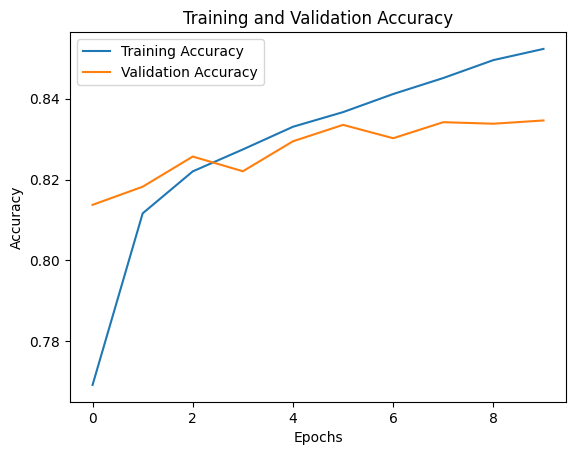

In [115]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

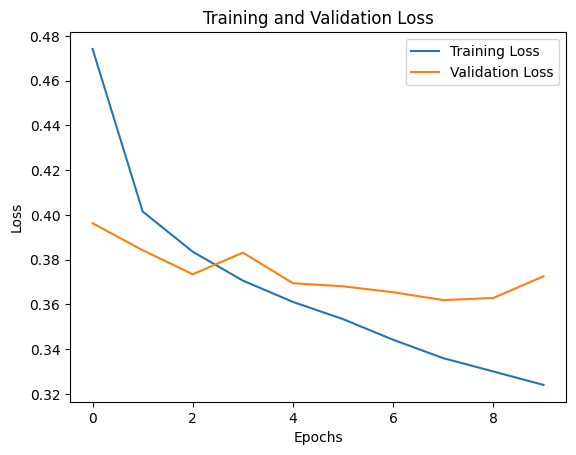

In [116]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [117]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 2s 2ms/step
              precision    recall  f1-score   support

           0       0.84      0.83      0.83     10584
           1       0.83      0.84      0.84     10585

    accuracy                           0.83     21169
   macro avg       0.83      0.83      0.83     21169
weighted avg       0.83      0.83      0.83     21169



## 1.4. Searching for Best Model Parameters

### 1.4.1. BiCNN

In [92]:
def bicnn_amazon(vocab_size, embedding_dim, learning_rate, embedding_matrix):
    inputs = Input(shape=(32,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=32, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # forward CNN (left-to-right processing)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    pool_fw = GlobalMaxPooling1D()(conv_fw) 

    # reverse input sequence to process right-to-left
    reversed_inputs = tf.reverse(inputs, axis=[1]) 
    embedding_rev = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                              input_length=32, weights=[embedding_matrix], 
                              trainable=False)(reversed_inputs)

    # backward CNN (right-to-left processing)
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding_rev)
    pool_bw = GlobalMaxPooling1D()(conv_bw) 

    # concatenating forward and backward feature representations
    concat = Concatenate()([pool_fw, pool_bw])

    dropout = Dropout(0.4)(concat)

    dense = Dense(128, activation='relu')(dropout)

    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [93]:
model_bicnn = bicnn_amazon(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [94]:
model_bicnn.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 tf.reverse_1 (TFOpLambda)      (None, 32)           0           ['input_5[0][0]']                
                                                                                                  
 embedding_14 (Embedding)       (None, 32, 300)      3600000     ['input_5[0][0]']                
                                                                                                  
 embedding_15 (Embedding)       (None, 32, 300)      3600000     ['tf.reverse_1[0][0]']           
                                                                                            

In [95]:
# train the model
history_bicnn = model_bicnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 33s 11ms/step - loss: 0.4229 - accuracy: 0.7981 - val_loss: 0.3897 - val_accuracy: 0.8137
Epoch 2/10
3087/3087 [==============================] - 29s 10ms/step - loss: 0.3749 - accuracy: 0.8232 - val_loss: 0.3749 - val_accuracy: 0.8239
Epoch 3/10
3087/3087 [==============================] - 29s 9ms/step - loss: 0.3540 - accuracy: 0.8336 - val_loss: 0.3657 - val_accuracy: 0.8296
Epoch 4/10
3087/3087 [==============================] - 29s 9ms/step - loss: 0.3384 - accuracy: 0.8429 - val_loss: 0.3603 - val_accuracy: 0.8365
Epoch 5/10
3087/3087 [==============================] - 29s 9ms/step - loss: 0.3248 - accuracy: 0.8503 - val_loss: 0.3590 - val_accuracy: 0.8367
Epoch 6/10
3087/3087 [==============================] - 29s 9ms/step - loss: 0.3123 - accuracy: 0.8574 - val_loss: 0.3556 - val_accuracy: 0.8398
Epoch 7/10
3087/3087 [==============================] - 30s 10ms/step - loss: 0.3025 - accuracy: 0.8617 - val_loss: 0.3515 - val

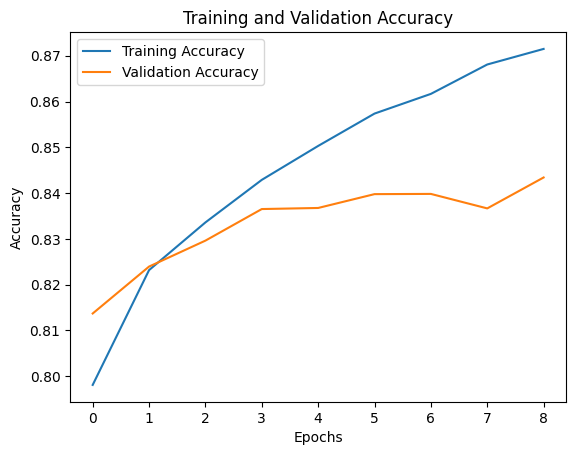

In [96]:
# plot accuracy on training and validation data
plt.plot(history_bicnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bicnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

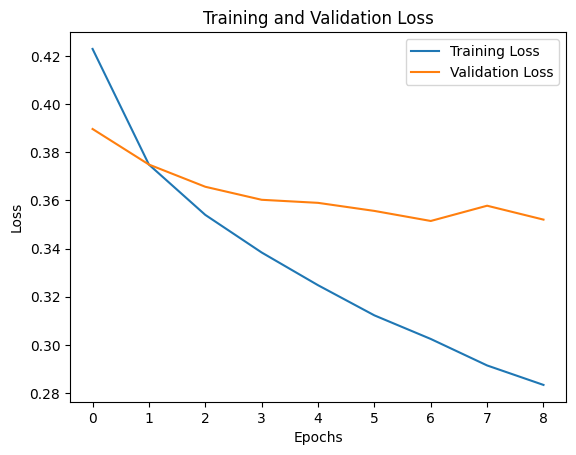

In [97]:
# plot loss on training and validation data
plt.plot(history_bicnn.history['loss'], label='Training Loss')
plt.plot(history_bicnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [98]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bicnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 2s 4ms/step
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     10584
           1       0.83      0.85      0.84     10585

    accuracy                           0.84     21169
   macro avg       0.84      0.84      0.84     21169
weighted avg       0.84      0.84      0.84     21169



### 1.4.2. TCN (Temporal Convolutional Network) 

In [162]:
def tcn_model_amazon(vocab_size, embedding_dim, embedding_matrix, learning_rate, dilation_rates=[1, 2, 4, 8]):
    inputs = Input(shape=(32,))
    
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=32, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    x = embedding  # initialize feature extraction pipeline
    
    # multiple dilated convolutional layers
    for rate in dilation_rates:
        residual = x
        x = Conv1D(filters=embedding_dim, kernel_size=3, activation='relu', padding='same', dilation_rate=rate)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        x = Add()([x, residual])
        x = Activation('relu')(x)

    pool = GlobalMaxPooling1D()(x)

    dense = Dense(128, activation='relu')(pool)

    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])

    return model

In [163]:
model_tcn = tcn_model_amazon(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [164]:
model_tcn.summary()

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 embedding_22 (Embedding)       (None, 32, 300)      3600000     ['input_9[0][0]']                
                                                                                                  
 conv1d_33 (Conv1D)             (None, 32, 300)      270300      ['embedding_22[0][0]']           
                                                                                                  
 batch_normalization_10 (BatchN  (None, 32, 300)     1200        ['conv1d_33[0][0]']              
 ormalization)                                                                              

In [165]:
# train the model
history_tcn = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10


ValueError: in user code:

    File "c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\keras\engine\training.py", line 993, in train_step
        y_pred = self(x, training=True)
    File "c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\senti

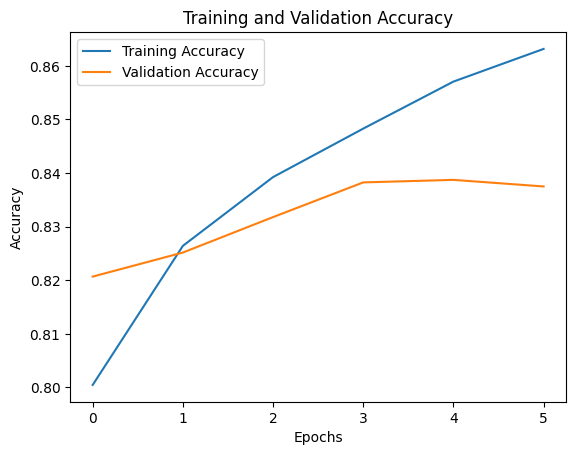

In [103]:
# plot accuracy on training and validation data
plt.plot(history_tcn.history['accuracy'], label='Training Accuracy')
plt.plot(history_tcn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

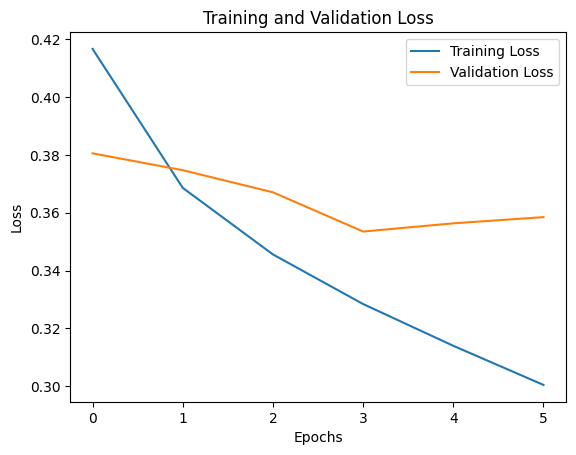

In [104]:
# plot loss on training and validation data
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [105]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_tcn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 10s 15ms/step
              precision    recall  f1-score   support

           0       0.86      0.81      0.83     10584
           1       0.82      0.87      0.84     10585

    accuracy                           0.84     21169
   macro avg       0.84      0.84      0.84     21169
weighted avg       0.84      0.84      0.84     21169



## 1.5. Model Evaluation on Test Data

In [118]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_df, max_length=max_length)

662/662 [==============================] - 2s 3ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.84      0.83      0.83     10583
           1       0.83      0.84      0.84     10582

    accuracy                           0.83     21165
   macro avg       0.83      0.83      0.83     21165
weighted avg       0.83      0.83      0.83     21165



## 1.6. Model Evaluation on Augmented Data

In [120]:
# load the augmented test sets
test_amazon_char_swap_file = '../data/preprocessed/amazon_test_char_swap.csv'
test_amazon_char_swap_df = pd.read_csv(test_amazon_char_swap_file, engine='python', encoding="ISO-8859-1")

test_amazon_embedding_file = '../data/preprocessed/amazon_test_embedding.csv'
test_amazon_embedding_df = pd.read_csv(test_amazon_embedding_file, engine='python', encoding="ISO-8859-1")

test_amazon_eda_file = '../data/preprocessed/amazon_test_eda.csv'
test_amazon_eda_df = pd.read_csv(test_amazon_eda_file, engine='python', encoding="ISO-8859-1")

In [123]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_char_swap_df, max_length=max_length)

662/662 [==============================] - 3s 4ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.75      0.74      0.74     10583
           1       0.74      0.76      0.75     10582

    accuracy                           0.75     21165
   macro avg       0.75      0.75      0.75     21165
weighted avg       0.75      0.75      0.75     21165



In [124]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_embedding_df, max_length=max_length)


662/662 [==============================] - 2s 3ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.79      0.76      0.78     10583
           1       0.77      0.80      0.79     10582

    accuracy                           0.78     21165
   macro avg       0.78      0.78      0.78     21165
weighted avg       0.78      0.78      0.78     21165



In [125]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_eda_df, max_length=max_length)


662/662 [==============================] - 2s 3ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.81      0.79      0.80     10583
           1       0.80      0.81      0.80     10582

    accuracy                           0.80     21165
   macro avg       0.80      0.80      0.80     21165
weighted avg       0.80      0.80      0.80     21165



## 1.7. Save Model

In [126]:
model_path = os.path.join(models_output_dir, "amazon_cnn_model.keras")
model_cnn.save(model_path)

# 2. LSTM Model - Sentiment140

## 2.1. Loading Data

In [127]:
# load the dataset
sentiment140_file = '../data/preprocessed/sentiment140.csv'
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', encoding="ISO-8859-1")

In [128]:
# preview the data
sentiment140_df.head()

,Polarity,Review
0,1,@Alicia_86 srry u get my tweet?
1,1,@jchiarelli TTS to take text Tweets to the pho...
2,1,Mmmm apple cinnomin oatmeal
3,1,@willwallaceii thanks man. the truth can be fu...
4,1,RAIN The plants and trees are happy ^~^


In [129]:
train_val_sentiment140_df, test_sentiment140_df = train_test_split(
    sentiment140_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=sentiment140_df['Polarity']
)

In [130]:
train_sentiment140_df, val_sentiment140_df = train_test_split(
    train_val_sentiment140_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_sentiment140_df['Polarity']
)

In [131]:
DataUtils.count_reviews_by_polarity(train_sentiment140_df)

Number of reviews with Polarity=1: 111996
Number of reviews with Polarity=0: 111996


In [132]:
DataUtils.count_reviews_by_polarity(val_sentiment140_df)

Number of reviews with Polarity=1: 24004
Number of reviews with Polarity=0: 24004


In [133]:
DataUtils.count_reviews_by_polarity(test_sentiment140_df)

Number of reviews with Polarity=1: 24000
Number of reviews with Polarity=0: 24000


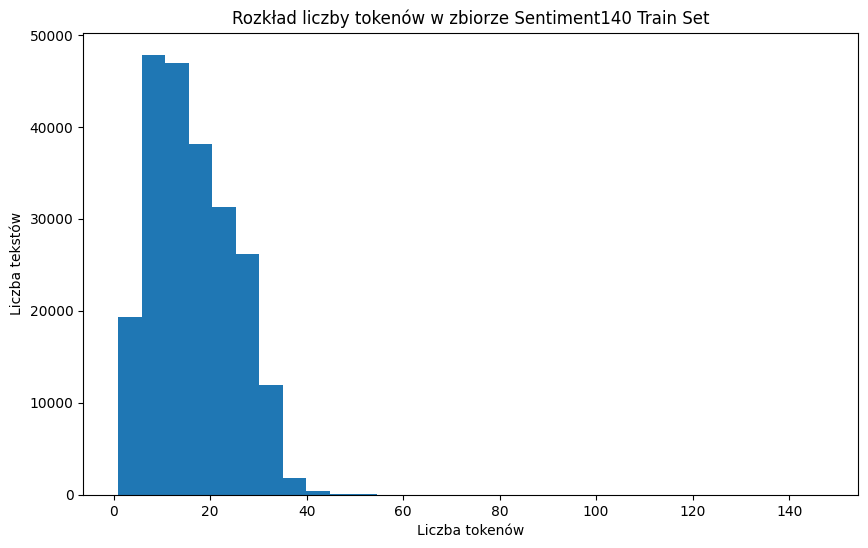

In [134]:
DataUtils.plot_token_distribution(train_sentiment140_df, "Sentiment140 Train Set")

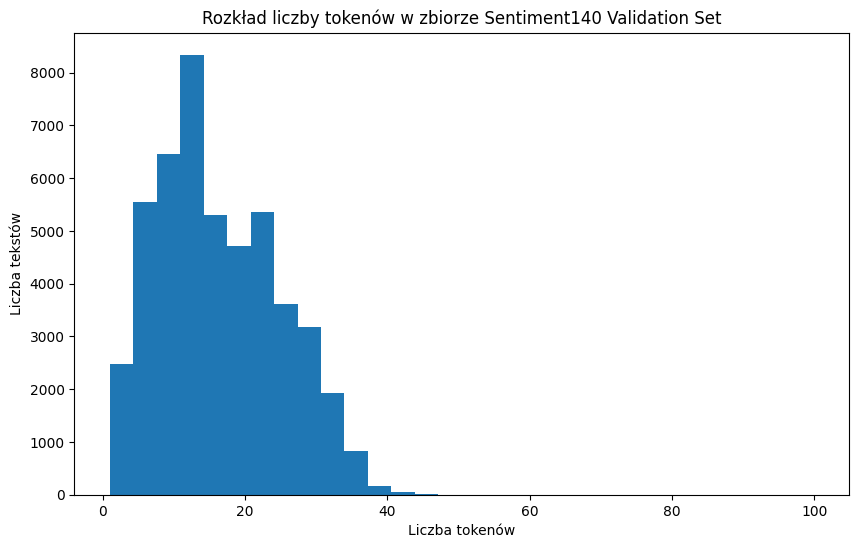

In [135]:
DataUtils.plot_token_distribution(val_sentiment140_df, "Sentiment140 Validation Set")

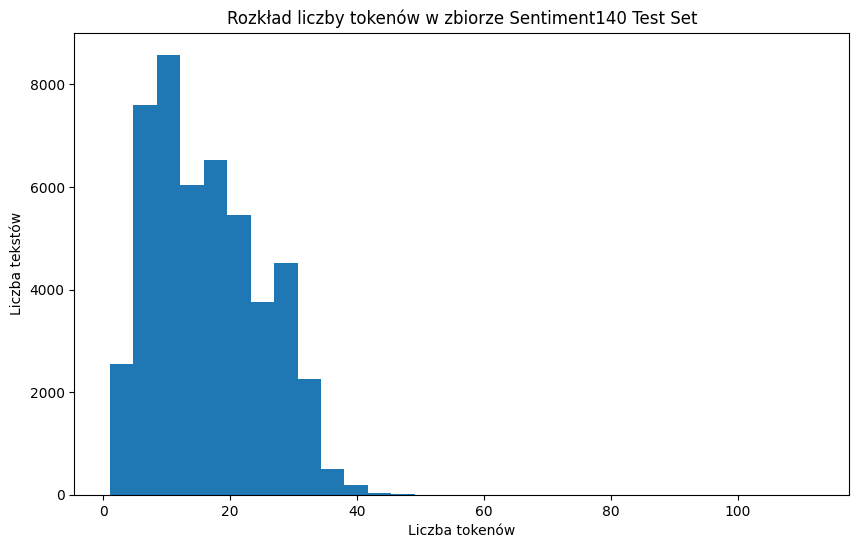

In [136]:
DataUtils.plot_token_distribution(test_sentiment140_df, "Sentiment140 Test Set")

## 2.2. Data Preprocessing

In [137]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 64  # maximum length of input sequences

In [138]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_sentiment140_df, max_length=max_length, vocab_size=vocab_size)

In [139]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_sentiment140_df, tokenizer, max_length)

In [140]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_sentiment140_df, tokenizer, max_length)

## 2.3. Model Training

In [141]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [142]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [173]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                input_length=max_length, weights=[embedding_matrix], 
                trainable=False),
    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [174]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [175]:
model_cnn.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_24 (Embedding)    (None, 64, 300)           3600000   
                                                                 
 conv1d_41 (Conv1D)          (None, 64, 256)           384256    
                                                                 
 global_max_pooling1d_21 (Gl  (None, 256)              0         
 obalMaxPooling1D)                                               
                                                                 
 dense_32 (Dense)            (None, 128)               32896     
                                                                 
 dropout_38 (Dropout)        (None, 128)               0         
                                                                 
 dense_33 (Dense)            (None, 1)                 129       
                                                      

In [176]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [177]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 129s 18ms/step - loss: 0.4837 - accuracy: 0.7668 - val_loss: 0.4509 - val_accuracy: 0.7872
Epoch 2/10
7000/7000 [==============================] - 128s 18ms/step - loss: 0.4358 - accuracy: 0.7962 - val_loss: 0.4387 - val_accuracy: 0.7923
Epoch 3/10
7000/7000 [==============================] - 128s 18ms/step - loss: 0.4097 - accuracy: 0.8106 - val_loss: 0.4309 - val_accuracy: 0.7991
Epoch 4/10
7000/7000 [==============================] - 127s 18ms/step - loss: 0.3849 - accuracy: 0.8238 - val_loss: 0.4449 - val_accuracy: 0.7967
Epoch 5/10
7000/7000 [==============================] - 128s 18ms/step - loss: 0.3592 - accuracy: 0.8361 - val_loss: 0.4789 - val_accuracy: 0.7992


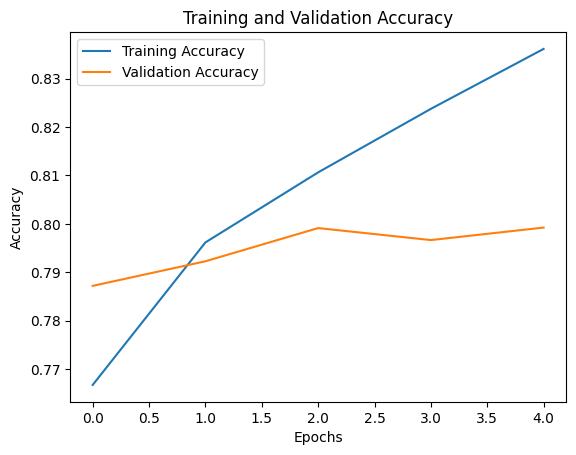

In [178]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

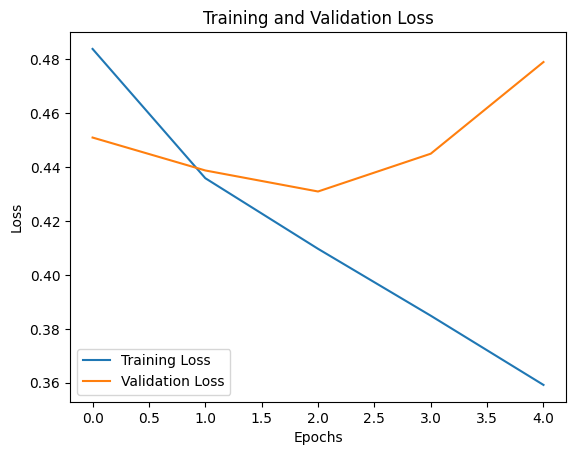

In [179]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [180]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 10s 7ms/step
              precision    recall  f1-score   support

           0       0.80      0.80      0.80     24004
           1       0.80      0.80      0.80     24004

    accuracy                           0.80     48008
   macro avg       0.80      0.80      0.80     48008
weighted avg       0.80      0.80      0.80     48008



## 2.4. Searching for Best Model Parameters

### 2.4.1. BiCNN

In [151]:
def bicnn_sentiment140(vocab_size, learning_rate, embedding_dim, embedding_matrix):
    inputs = Input(shape=(64,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=64, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # forward CNN (left-to-right processing)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv_fw = BatchNormalization()(conv_fw)
    pool_fw = GlobalMaxPooling1D()(conv_fw)

    # reverse input sequence to process right-to-left
    reversed_inputs = tf.reverse(inputs, axis=[1])
    embedding_rev = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                              input_length=64, weights=[embedding_matrix], 
                              trainable=False)(reversed_inputs)
                              
    # backward CNN (right-to-left processing)
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding_rev)
    conv_bw = BatchNormalization()(conv_bw)
    pool_bw = GlobalMaxPooling1D()(conv_bw)

    # Połączenie obu strumieni
    concat = Concatenate()([pool_fw, pool_bw])
    dropout = Dropout(0.5)(concat)

    # Warstwa gęsta
    dense = Dense(256, activation='relu')(dropout)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), metrics=['accuracy'])
    
    return model

In [152]:
model_bicnn = bicnn_sentiment140(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [153]:
model_bicnn.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 tf.reverse_2 (TFOpLambda)      (None, 64)           0           ['input_7[0][0]']                
                                                                                                  
 embedding_19 (Embedding)       (None, 64, 300)      3600000     ['input_7[0][0]']                
                                                                                                  
 embedding_20 (Embedding)       (None, 64, 300)      3600000     ['tf.reverse_2[0][0]']           
                                                                                            

In [156]:
# train the model
history_bicnn = model_bicnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 158s 23ms/step - loss: 0.4288 - accuracy: 0.8005 - val_loss: 0.4280 - val_accuracy: 0.8023
Epoch 2/10
7000/7000 [==============================] - 157s 22ms/step - loss: 0.4216 - accuracy: 0.8039 - val_loss: 0.4284 - val_accuracy: 0.7994
Epoch 3/10
7000/7000 [==============================] - 163s 23ms/step - loss: 0.4166 - accuracy: 0.8071 - val_loss: 0.4212 - val_accuracy: 0.8067
Epoch 4/10
7000/7000 [==============================] - 163s 23ms/step - loss: 0.4101 - accuracy: 0.8103 - val_loss: 0.4188 - val_accuracy: 0.8077
Epoch 5/10
7000/7000 [==============================] - 150s 21ms/step - loss: 0.4065 - accuracy: 0.8124 - val_loss: 0.4196 - val_accuracy: 0.8063
Epoch 6/10
7000/7000 [==============================] - 154s 22ms/step - loss: 0.4022 - accuracy: 0.8154 - val_loss: 0.4193 - val_accuracy: 0.8055


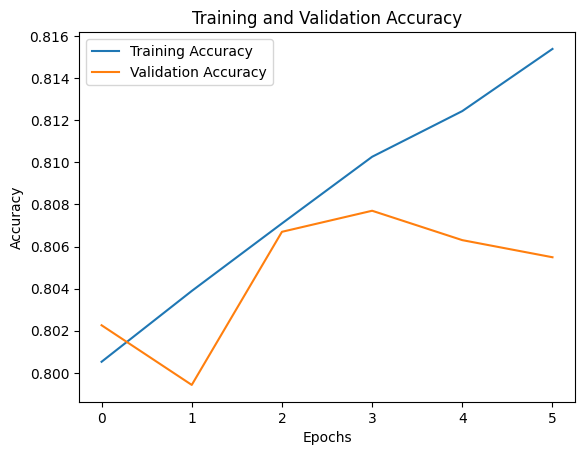

In [157]:
# plot accuracy on training and validation data
plt.plot(history_bicnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bicnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

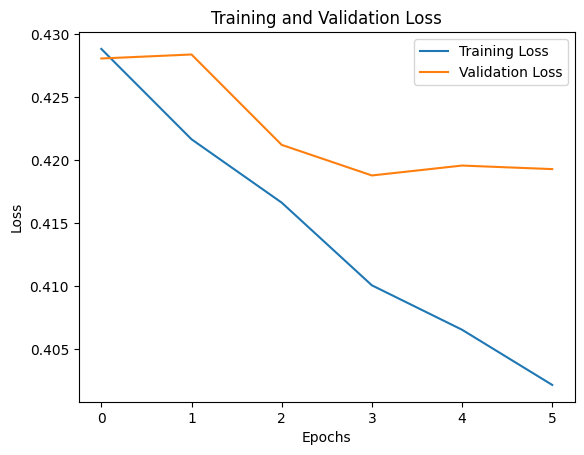

In [158]:
# plot loss on training and validation data
plt.plot(history_bicnn.history['loss'], label='Training Loss')
plt.plot(history_bicnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [159]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bicnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 11s 7ms/step
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     24004
           1       0.81      0.81      0.81     24004

    accuracy                           0.81     48008
   macro avg       0.81      0.81      0.81     48008
weighted avg       0.81      0.81      0.81     48008



### 2.4.2. TCN (Temporal Convolutional Network) 

In [166]:
def tcn_model_sentiment140(vocab_size, learning_rate, embedding_dim, embedding_matrix, dilation_rates=[1,2,4,8]):
    inputs = Input(shape=(64,))
    
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=64, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    x = embedding # initialize feature extraction pipeline

    # multiple dilated convolutional layers
    for rate in dilation_rates:
        residual = x
        x = Conv1D(filters=embedding_dim, kernel_size=3, activation='relu', padding='same', dilation_rate=rate)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        x = Add()([x, residual]) 
        x = Activation('relu')(x)

    pool = GlobalMaxPooling1D()(x)

    dense = Dense(256, activation='relu')(pool)

    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [167]:
model_tcn = tcn_model_sentiment140(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [168]:
model_tcn.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 64)]         0           []                               
                                                                                                  
 embedding_23 (Embedding)       (None, 64, 300)      3600000     ['input_10[0][0]']               
                                                                                                  
 conv1d_37 (Conv1D)             (None, 64, 300)      270300      ['embedding_23[0][0]']           
                                                                                                  
 batch_normalization_14 (BatchN  (None, 64, 300)     1200        ['conv1d_37[0][0]']              
 ormalization)                                                                              

In [169]:
# train the model
history_tcn = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 770s 110ms/step - loss: 0.5388 - accuracy: 0.7441 - val_loss: 0.4709 - val_accuracy: 0.7759
Epoch 2/10
7000/7000 [==============================] - 768s 110ms/step - loss: 0.4582 - accuracy: 0.7848 - val_loss: 0.4367 - val_accuracy: 0.7970
Epoch 3/10
7000/7000 [==============================] - 779s 111ms/step - loss: 0.4378 - accuracy: 0.7967 - val_loss: 0.4300 - val_accuracy: 0.8037
Epoch 4/10
7000/7000 [==============================] - 764s 109ms/step - loss: 0.4216 - accuracy: 0.8059 - val_loss: 0.4180 - val_accuracy: 0.8080
Epoch 5/10
7000/7000 [==============================] - 750s 107ms/step - loss: 0.4093 - accuracy: 0.8122 - val_loss: 0.4161 - val_accuracy: 0.8085
Epoch 6/10
7000/7000 [==============================] - 810s 116ms/step - loss: 0.3991 - accuracy: 0.8179 - val_loss: 0.4158 - val_accuracy: 0.8112
Epoch 7/10
7000/7000 [==============================] - 753s 108ms/step - loss: 0.3897 - accuracy: 0.8224 - val_

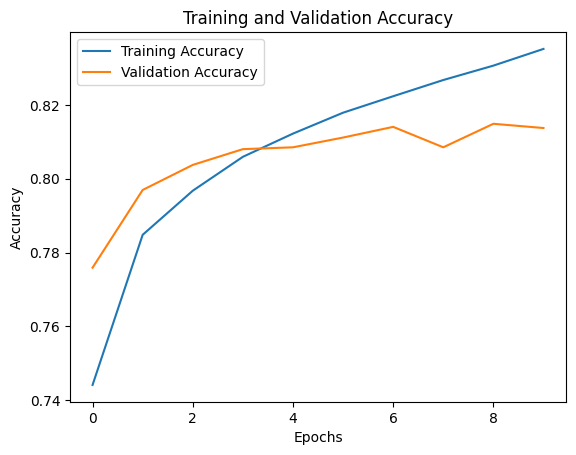

In [170]:
# plot accuracy on training and validation data
plt.plot(history_tcn.history['accuracy'], label='Training Accuracy')
plt.plot(history_tcn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

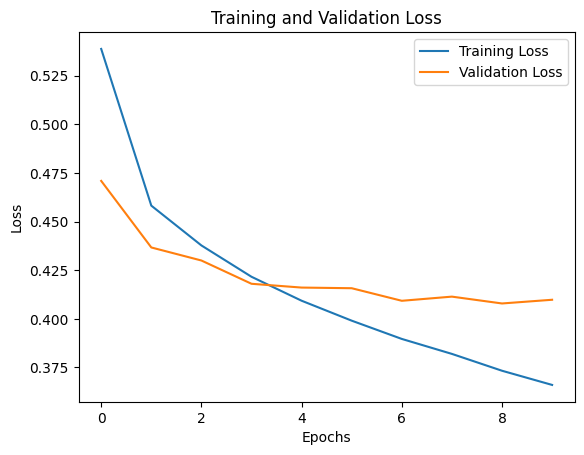

In [171]:
# plot loss on training and validation data
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [172]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_tcn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 40s 27ms/step
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     24004
           1       0.81      0.81      0.81     24004

    accuracy                           0.81     48008
   macro avg       0.81      0.81      0.81     48008
weighted avg       0.81      0.81      0.81     48008



## 2.5. Model Evaluation on Test Data

In [181]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_df, max_length=max_length)

1500/1500 [==============================] - 12s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     24000
           1       0.81      0.81      0.81     24000

    accuracy                           0.81     48000
   macro avg       0.81      0.81      0.81     48000
weighted avg       0.81      0.81      0.81     48000



## 2.6. Model Evaluation on Augmented Data

In [182]:
# load the augmented test sets
test_sentiment140_char_swap_file = '../data/preprocessed/sentiment140_test_char_swap.csv'
test_sentiment140_char_swap_df = pd.read_csv(test_sentiment140_char_swap_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_embedding_file = '../data/preprocessed/sentiment140_test_embedding.csv'
test_sentiment140_embedding_df = pd.read_csv(test_sentiment140_embedding_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_eda_file = '../data/preprocessed/sentiment140_test_eda.csv'
test_sentiment140_eda_df = pd.read_csv(test_sentiment140_eda_file, engine='python', encoding="ISO-8859-1")

In [183]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_char_swap_df, max_length=max_length)

1500/1500 [==============================] - 12s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.76      0.78     24000
           1       0.77      0.81      0.79     24000

    accuracy                           0.78     48000
   macro avg       0.78      0.78      0.78     48000
weighted avg       0.78      0.78      0.78     48000



In [184]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_embedding_df, max_length=max_length)


1500/1500 [==============================] - 11s 7ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.76      0.78     24000
           1       0.77      0.81      0.79     24000

    accuracy                           0.78     48000
   macro avg       0.78      0.78      0.78     48000
weighted avg       0.78      0.78      0.78     48000



In [185]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_eda_df, max_length=max_length)


1500/1500 [==============================] - 11s 7ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.78      0.79     24000
           1       0.78      0.80      0.79     24000

    accuracy                           0.79     48000
   macro avg       0.79      0.79      0.79     48000
weighted avg       0.79      0.79      0.79     48000



## 2.7. Save Model

In [186]:
model_path = os.path.join(models_output_dir, "sentiment140_cnn_model.keras")
model_bicnn.save(model_path)

# 3. LSTM Model - Yelp Reviews

## 3.1. Loading Data

In [8]:
# load the dataset
yelp_file = '../data/preprocessed/yelp.csv'
yelp_df = pd.read_csv(yelp_file, engine='python', encoding="ISO-8859-1")

In [9]:
# preview the data
yelp_df.head()

,Polarity,Review
0,0,The food was pretty good but the server was so...
1,0,Horrible manager! She told us we only needed t...
2,1,I Love the Black Bean Burger. So much so I cam...
3,0,Off the beaten path and you can either park yo...
4,1,"Awesome NYC pizza, my second favorite NYC styl..."


In [10]:
train_val_yelp_df, test_yelp_df = train_test_split(
    yelp_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=yelp_df['Polarity']
)

In [11]:
train_yelp_df, val_yelp_df = train_test_split(
    train_val_yelp_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_yelp_df['Polarity']
)

In [12]:
DataUtils.count_reviews_by_polarity(train_yelp_df)

Number of reviews with Polarity=1: 39199
Number of reviews with Polarity=0: 39198


In [13]:
DataUtils.count_reviews_by_polarity(val_yelp_df)

Number of reviews with Polarity=1: 8401
Number of reviews with Polarity=0: 8402


In [14]:
DataUtils.count_reviews_by_polarity(test_yelp_df)

Number of reviews with Polarity=1: 8400
Number of reviews with Polarity=0: 8400


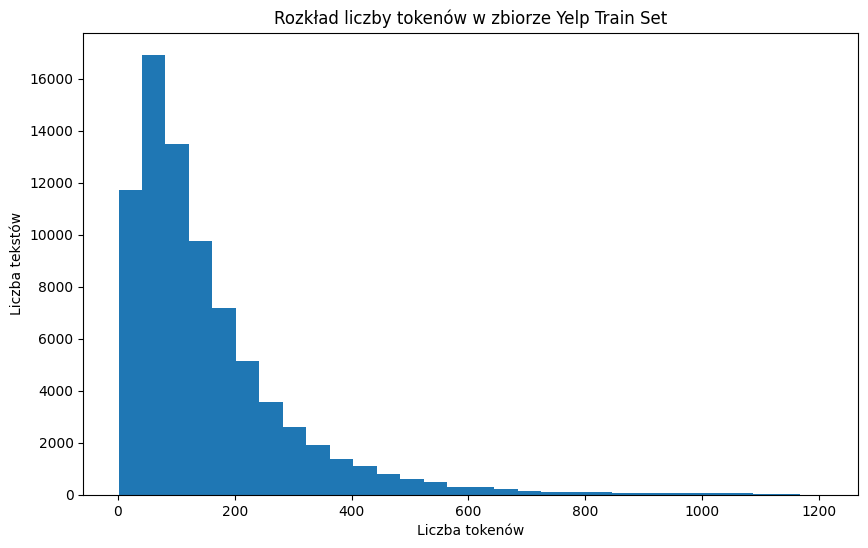

In [15]:
DataUtils.plot_token_distribution(train_yelp_df, "Yelp Train Set")

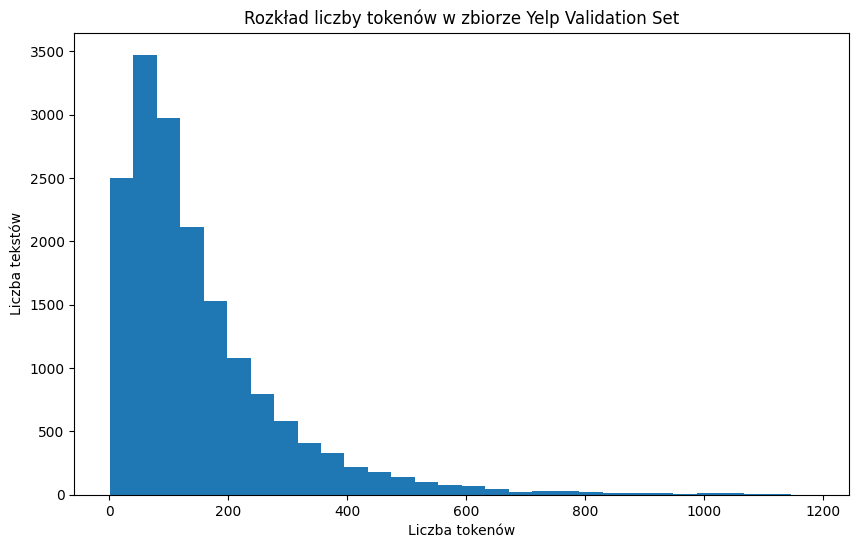

In [16]:
DataUtils.plot_token_distribution(val_yelp_df, "Yelp Validation Set")

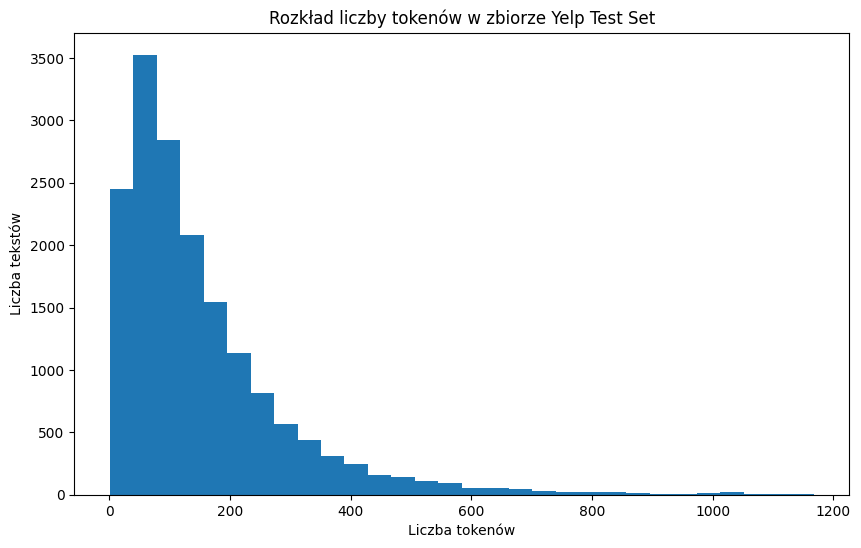

In [17]:
DataUtils.plot_token_distribution(test_yelp_df, "Yelp Test Set")

## 3.2. Data Preprocessing

In [18]:
# set preprocessing parameters
vocab_size = 15000  # maximum number of words in the tokenizer
max_length = 256  # maximum length of input sequences

In [19]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_yelp_df, max_length=max_length, vocab_size=vocab_size)

In [20]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_yelp_df, tokenizer, max_length)

In [21]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_yelp_df, tokenizer, max_length)

## 3.3. Model Training

In [22]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [23]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (15000, 300)


In [27]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=256, weights=[embedding_matrix], trainable=False),
    
    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    
    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    
    GlobalMaxPooling1D(),
    
    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(1, activation='sigmoid')
])

In [28]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [29]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 333s 135ms/step - loss: 0.3550 - accuracy: 0.8473 - val_loss: 0.2434 - val_accuracy: 0.8992
Epoch 2/10
2450/2450 [==============================] - 337s 138ms/step - loss: 0.2333 - accuracy: 0.9057 - val_loss: 0.2162 - val_accuracy: 0.9120
Epoch 3/10
2450/2450 [==============================] - 309s 126ms/step - loss: 0.1984 - accuracy: 0.9224 - val_loss: 0.1913 - val_accuracy: 0.9226
Epoch 4/10
 851/2450 [=========>....................] - ETA: 3:34 - loss: 0.1641 - accuracy: 0.9372

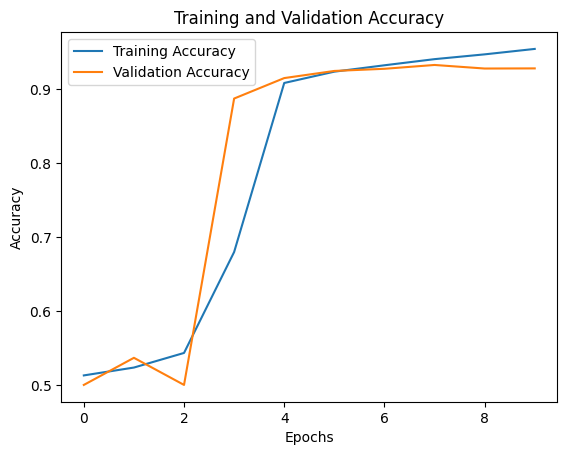

In [114]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

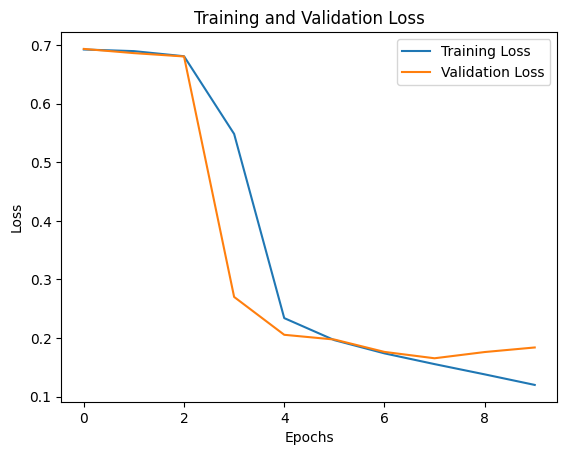

In [115]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [116]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 7s 13ms/step
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      8402
           1       0.94      0.92      0.93      8401

    accuracy                           0.93     16803
   macro avg       0.93      0.93      0.93     16803
weighted avg       0.93      0.93      0.93     16803



## 3.4. Searching for Best Model Parameters

### 3.4.1. BiCNN

In [ ]:
def bicnn(vocab_size, learning_rate, embedding_dim, embedding_matrix):
    inputs = Input(shape=(256,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=256, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # CNN od lewej do prawej
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv_fw = BatchNormalization()(conv_fw)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(conv_fw)
    conv_fw = BatchNormalization()(conv_fw)
    pool_fw1 = GlobalMaxPooling1D()(conv_fw)
    pool_fw2 = GlobalAveragePooling1D()(conv_fw)

    # CNN od prawej do lewej
    reversed_inputs = tf.reverse(inputs, axis=[1])
    embedding_rev = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                              input_length=256, weights=[embedding_matrix], 
                              trainable=False)(reversed_inputs)
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding_rev)
    conv_bw = BatchNormalization()(conv_bw)
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(conv_bw)
    conv_bw = BatchNormalization()(conv_bw)
    pool_bw1 = GlobalMaxPooling1D()(conv_bw)
    pool_bw2 = GlobalAveragePooling1D()(conv_bw)

    concat = Concatenate()([pool_fw1, pool_fw2, pool_bw1, pool_bw2])
    dropout = Dropout(0.5)(concat)

    dense = Dense(256, activation='relu')(dropout)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['loss'])
    
    return model

In [133]:
model_bilstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [134]:
# train the model
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 146s 58ms/step - loss: 0.5373 - accuracy: 0.7294 - val_loss: 0.3868 - val_accuracy: 0.8448
Epoch 2/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.2631 - accuracy: 0.8935 - val_loss: 0.2214 - val_accuracy: 0.9075
Epoch 3/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.2037 - accuracy: 0.9192 - val_loss: 0.1874 - val_accuracy: 0.9229
Epoch 4/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.1781 - accuracy: 0.9299 - val_loss: 0.1714 - val_accuracy: 0.9301
Epoch 5/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.1608 - accuracy: 0.9372 - val_loss: 0.1606 - val_accuracy: 0.9336
Epoch 6/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.1424 - accuracy: 0.9454 - val_loss: 0.1578 - val_accuracy: 0.9352
Epoch 7/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.1279 - accuracy: 0.9506 - val_loss: 0

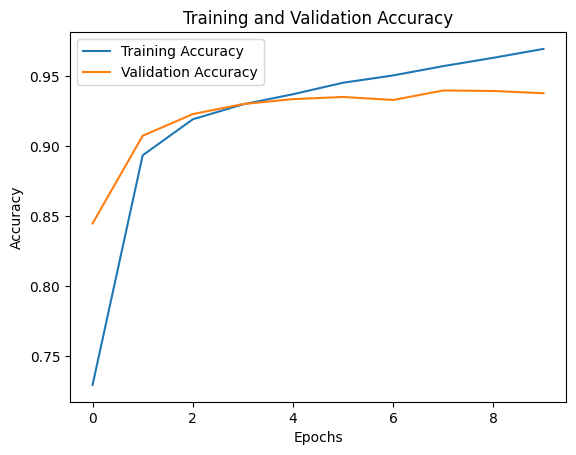

In [135]:
# plot accuracy on training and validation data
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

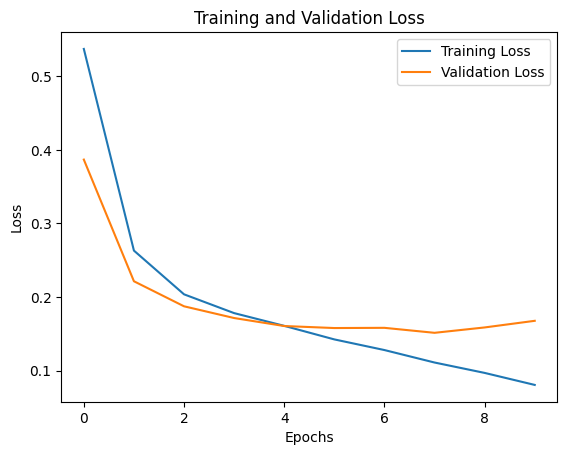

In [136]:
# plot loss on training and validation data
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [137]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bilstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 14s 24ms/step
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      8402
           1       0.95      0.93      0.94      8401

    accuracy                           0.94     16803
   macro avg       0.94      0.94      0.94     16803
weighted avg       0.94      0.94      0.94     16803



### 3.4.2. BiLSTM + Attention

In [138]:
model_attention = build_attention_lstm_model_yelp(vocab_size=vocab_size, embedding_dim=embedding_dim, max_length=max_length, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

In [139]:
# train the model
history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 155s 61ms/step - loss: 0.3329 - accuracy: 0.8466 - val_loss: 0.2200 - val_accuracy: 0.9131
Epoch 2/10
2450/2450 [==============================] - 149s 61ms/step - loss: 0.2009 - accuracy: 0.9206 - val_loss: 0.1814 - val_accuracy: 0.9253
Epoch 3/10
2450/2450 [==============================] - 145s 59ms/step - loss: 0.1712 - accuracy: 0.9334 - val_loss: 0.1659 - val_accuracy: 0.9322
Epoch 4/10
2450/2450 [==============================] - 140s 57ms/step - loss: 0.1487 - accuracy: 0.9419 - val_loss: 0.1613 - val_accuracy: 0.9329
Epoch 5/10
2450/2450 [==============================] - 141s 58ms/step - loss: 0.1302 - accuracy: 0.9508 - val_loss: 0.1695 - val_accuracy: 0.9350
Epoch 6/10
2450/2450 [==============================] - 147s 60ms/step - loss: 0.1092 - accuracy: 0.9590 - val_loss: 0.1810 - val_accuracy: 0.9327


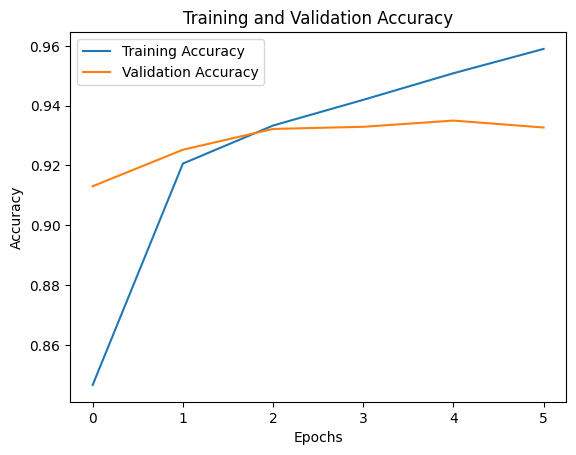

In [140]:
# plot accuracy on training and validation data
plt.plot(history_attention.history['accuracy'], label='Training Accuracy')
plt.plot(history_attention.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

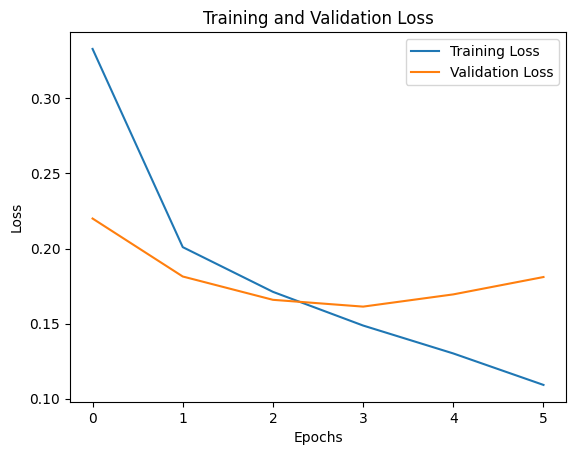

In [141]:
# plot loss on training and validation data
plt.plot(history_attention.history['loss'], label='Training Loss')
plt.plot(history_attention.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [142]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_attention.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 15s 27ms/step
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      8402
           1       0.92      0.95      0.93      8401

    accuracy                           0.93     16803
   macro avg       0.93      0.93      0.93     16803
weighted avg       0.93      0.93      0.93     16803



## 3.5. Model Evaluation on Test Data

In [144]:
train_cnn.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_yelp_df, max_length=max_length)

525/525 [==============================] - 14s 27ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      8400
           1       0.92      0.95      0.94      8400

    accuracy                           0.94     16800
   macro avg       0.94      0.94      0.94     16800
weighted avg       0.94      0.94      0.94     16800



## 3.6. Model Evaluation on Augmented Data

In [145]:
# load the augmented test sets
test_yelp_char_swap_file = '../data/preprocessed/yelp_test_char_swap.csv'
test_yelp_char_swap_df = pd.read_csv(test_yelp_char_swap_file, engine='python', encoding="ISO-8859-1")

test_yelp_transform_file = '../data/preprocessed/yelp_test_transform.csv'
test_yelp_transform_df = pd.read_csv(test_yelp_transform_file, engine='python', encoding="ISO-8859-1")

test_yelp_combined_file = '../data/preprocessed/yelp_test_combined.csv'
test_yelp_combined_df = pd.read_csv(test_yelp_combined_file, engine='python', encoding="ISO-8859-1")

In [146]:
train_cnn.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_yelp_char_swap_df, max_length=max_length)

525/525 [==============================] - 13s 24ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.89      0.78      0.84      8400
           1       0.81      0.91      0.85      8400

    accuracy                           0.85     16800
   macro avg       0.85      0.85      0.84     16800
weighted avg       0.85      0.85      0.84     16800



In [147]:
train_cnn.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_yelp_transform_df, max_length=max_length)


525/525 [==============================] - 13s 25ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.93      0.90      0.91      8400
           1       0.90      0.93      0.92      8400

    accuracy                           0.91     16800
   macro avg       0.91      0.91      0.91     16800
weighted avg       0.91      0.91      0.91     16800



In [148]:
train_cnn.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_yelp_combined_df, max_length=max_length)


525/525 [==============================] - 14s 27ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      8400
           1       0.78      0.89      0.83      8400

    accuracy                           0.82     16800
   macro avg       0.83      0.82      0.82     16800
weighted avg       0.83      0.82      0.82     16800



## 3.7. Save Model

In [149]:
model_path = os.path.join(models_output_dir, "yelp_lstm_model.keras")
model_attention.save(model_path)